In [ ]:
#loading housing dataset
import pandas as pd

df = pd.read_csv('data/housing.csv')
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Loading housing dataset

In [ ]:

print(df.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Check for missing data

In [ ]:

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Some missing values in  total_bedrooms so we want to clean that using the median.
We use median to fill in these values instead of mean because the median is not effected by extreme outliers and the cap is at $500,000 so there is a decent amount of outliers

In [ ]:
#getting the descriptive statistics
print(df[['median_house_value', 'population', 'median_income']].describe())


       median_house_value    population  median_income
count        20640.000000  20640.000000   20640.000000
mean        206855.816909   1425.476744       3.870671
std         115395.615874   1132.462122       1.899822
min          14999.000000      3.000000       0.499900
25%         119600.000000    787.000000       2.563400
50%         179700.000000   1166.000000       3.534800
75%         264725.000000   1725.000000       4.743250
max         500001.000000  35682.000000      15.000100


Mean:
House value: $206,855
This is the average across all 20,640 districts

Median:

House value: $179,700 (the 50% row in your describe output)
The mean is higher than the median shows us that the data is skewed right by expensive properties

Standard Deviation:

House value: $115,396
On average, house prices differ from the mean by about $115,000, a wide spread



In [3]:

print(df[['median_house_value', 'population', 'median_income']].var())

median_house_value    1.331615e+10
population            1.282470e+06
median_income         3.609323e+00
dtype: float64


Describe does not have variance so this extra cell is just for finding the variance

Variance:

House value: 1.33 × 10¹⁰ (or 13,316,150,000)
This is a very large number which reflects how spread out house prices are across California

In [5]:
print(df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False))

ocean_proximity
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
<1H OCEAN     240084.285464
INLAND        124805.392001
Name: median_house_value, dtype: float64


In [6]:
df['pop_group'] = pd.cut(df['population'],
    bins=[0, 500, 1000, 2000, 5000, 100000],
    labels=['Very Low (0-500)', 'Low (500-1,000)', 'Medium (1,000-2,000)', 'High (2,000-5,000)', 'Very High (5,000+)'])

print(df.groupby('pop_group')['median_house_value'].mean().round(2))

pop_group
Very Low (0-500)        204842.39
Low (500-1,000)         215581.19
Medium (1,000-2,000)    203448.99
High (2,000-5,000)      201428.41
Very High (5,000+)      201602.64
Name: median_house_value, dtype: float64


Group Statistics: We grouped house values by ocean proximity to investigate RQ1, and by population size to investigate RQ2. The ocean proximity grouping shows a clear pattern, coastal properties are significantly more expensive than inland ones. The population grouping shows prices remain flat regardless of population density, suggesting population is a weak predictor of price.

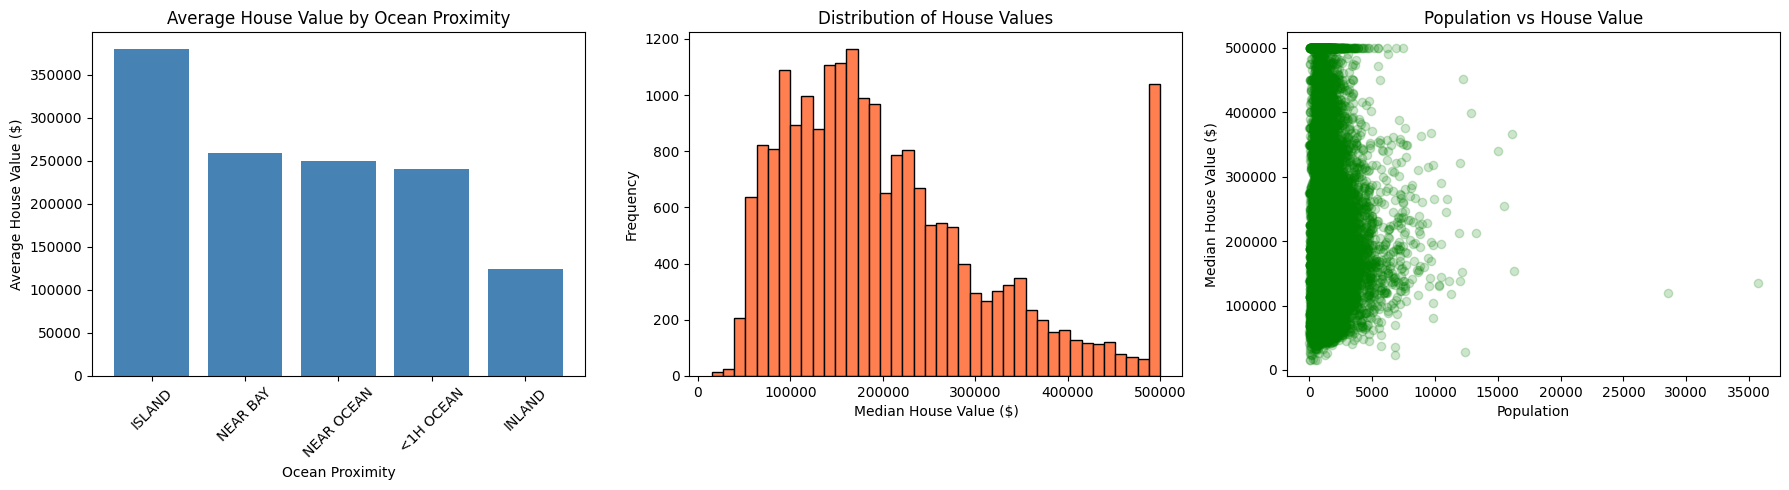

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot: Average house value by ocean proximity
ocean_avg = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False)
axes[0].bar(ocean_avg.index, ocean_avg.values, color='steelblue')
axes[0].set_title('Average House Value by Ocean Proximity')
axes[0].set_xlabel('Ocean Proximity')
axes[0].set_ylabel('Average House Value ($)')
axes[0].tick_params(axis='x', rotation=45)

# Histogram: Distribution of house values
axes[1].hist(df['median_house_value'], bins=40, color='coral', edgecolor='black')
axes[1].set_title('Distribution of House Values')
axes[1].set_xlabel('Median House Value ($)')
axes[1].set_ylabel('Frequency')

# Scatter plot: Population vs House Value
axes[2].scatter(df['population'], df['median_house_value'], alpha=0.2, color='green')
axes[2].set_title('Population vs House Value')
axes[2].set_xlabel('Population')
axes[2].set_ylabel('Median House Value ($)')

plt.tight_layout()
plt.show()

In [10]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn'])

CompletedProcess(args=['pip', 'install', 'scikit-learn'], returncode=0)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[['population', 'median_income']]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f'R² Score: {r2_score(y_test, y_pred):.4f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}')
print(f'Population coefficient: {model.coef_[0]:.4f}')
print(f'Income coefficient: {model.coef_[1]:.4f}')

R² Score: 0.4594
RMSE: $84,164.63
Population coefficient: -2.9367
Income coefficient: 41941.0781


We used linear regression to predict median house value (y) using population and median income (X). The model achieved an R² of 0.46, meaning it explains 46% of the variation in house prices. The RMSE of $84,164 tells us the average prediction error. The income coefficient of 41,941 means that for every unit increase in median income, house value increases by about $42,000. The population coefficient of -2.94 shows population has almost no effect on price.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create binary target: 1 = above median price, 0 = below
median_price = df['median_house_value'].median()
df['high_value'] = (df['median_house_value'] > median_price).astype(int)

# Encode ocean_proximity
df['ocean_encoded'] = pd.Categorical(df['ocean_proximity']).codes

X = df[['population', 'ocean_encoded', 'median_income']]
y = df['high_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

print(f'Accuracy: {accuracy_score(y_test, clf.predict(X_test)):.4f}')
print(classification_report(y_test, clf.predict(X_test)))

Accuracy: 0.8004
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2077
           1       0.79      0.81      0.80      2051

    accuracy                           0.80      4128
   macro avg       0.80      0.80      0.80      4128
weighted avg       0.80      0.80      0.80      4128



We used a Decision Tree Classifier to predict whether a house is above or below the median house value of $179,700 (binary classification: 1 = above, 0 = below). The features used were population, ocean proximity (encoded as a number), and median income. The model achieved 80% accuracy, meaning it correctly classified 4 out of every 5 houses. The balanced precision and recall scores of 0.80 for both classes show the model performs equally well at identifying expensive and affordable homes.

In this project, we investigated two research questions using the California Housing Prices dataset.
RQ1: Does ocean proximity influence housing prices?
Yes, ocean proximity significantly influences housing prices. Our descriptive statistics showed that inland homes average $124,805, roughly half the price of coastal properties which average between $240,000 and $380,000. This was supported by our bar chart visualization and confirmed by our Decision Tree model, which used ocean proximity as one of its key features and achieved 80% accuracy.
RQ2: Does population of an area influence housing prices?
Population has very little influence on housing prices. Our population groupby table showed that average house prices remain flat between $201,000 and $215,000 regardless of how densely populated the block is. Our linear regression confirmed this with a population coefficient of just -2.94, meaning each additional person in a block only changes the house value by less than $3.
Overall Finding:
Ocean proximity and median income are the strongest drivers of housing prices in California. Population size alone is not a meaningful predictor of house value.